In [8]:
################################################################
### Import Library
################################################################
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from timeit import default_timer
import torch.nn.functional as F
import pyekfmm as fmm

## check GPU availability
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [9]:
################################################################
### Build Vanilla FNO structure
################################################################
class SpectralConv2d(nn.Module):
    """2D Spectral Convolutional Layer using Fourier Transform."""
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, modes1, modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1) // 2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))


class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP, self).__init__()
        self.mlp1 = nn.Conv2d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv2d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.relu(x)
        x = self.mlp2(x)
        return x



class UKFNO2d(nn.Module):
    """Fourier Neural Operator for 2D data."""
    def __init__(self, modes1, modes2, width):
        super().__init__()
        
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 4
        self.p = nn.Linear(3, self.width)
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.mlp0 = MLP(self.width, self.width, self.width)
        self.mlp1 = MLP(self.width, self.width, self.width)
        self.mlp2 = MLP(self.width, self.width, self.width)
        self.mlp3 = MLP(self.width, self.width, self.width)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)
        self.q = MLP(self.width, 1, self.width * 4)

    def forward(self, x):
        x = x.to(torch.float32)
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = self.p(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0, self.padding, 0, self.padding])

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = F.gelu(x1 + x2)

        
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = F.gelu(x1 + x2)


        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = F.gelu(x1 + x2)


        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = F.gelu(x1 + x2)

        x = x[..., :-self.padding, :-self.padding]
        x = self.q(x)
        x = x.permute(0, 2, 3, 1)
        return x

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.linspace(0, 1, size_x, dtype=torch.float, device=device)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.linspace(0, 1, size_y, dtype=torch.float, device=device)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1)

In [11]:
################################################################
### Define the training function
################################################################

def count_params(model):
    """Count the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train(model, train_loader, valid_loader, epochs, optimizer, scheduler, criterion, device, ntrain, batch_size):
    model.train()
    losses = {'train': [], 'valid': []}
    
    for epoch in range(epochs):
        # Training phase
        t1 = default_timer()
        train_loss = 0
        for batch_inputs, batch_labels in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_inputs)
            loss = criterion(outputs.view(batch_size, -1), batch_labels.view(batch_size, -1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        scheduler.step()
        
        # Validation phase
        model.eval()
        valid_loss = 0
        with torch.no_grad():
            for batch_inputs, batch_labels in valid_loader:
                inputs, labels = batch_inputs.float(), batch_labels.float()
                outputs = model(batch_inputs)
                # print(outputs.shape, batch_labels.shape)
                loss = criterion(outputs.view(batch_size, -1), batch_labels.view(batch_size, -1))
                valid_loss += loss.item()
        model.train()
        
        # Average losses
        train_loss /= ntrain
        valid_loss /= nvalid
        
        losses['train'].append(train_loss)
        losses['valid'].append(valid_loss)
        t2 = default_timer()

        # Print losses every 50 epochs
        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.3e}, Val Loss: {valid_loss:.3e}, Time: {t2 - t1:.3f} s")
    
    return model, losses

Shape of velocity model 1: (70, 70)


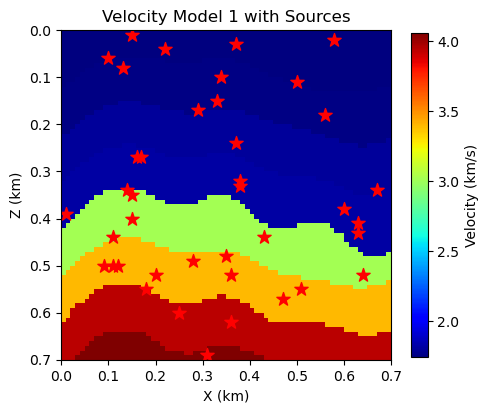

source location: 43 44
source location: 58 2
source location: 33 15
source location: 16 27
source location: 15 40
source location: 60 38
source location: 37 3
source location: 1 39
source location: 63 43
source location: 20 52
source location: 38 33
source location: 17 27
source location: 9 50
source location: 38 32
source location: 14 34
source location: 51 55
source location: 11 50
source location: 36 62
source location: 50 11
source location: 35 48
source location: 25 60
source location: 18 55
source location: 63 41
source location: 31 69
source location: 37 24
source location: 22 4
source location: 64 52
source location: 10 6
source location: 67 34
source location: 15 35
source location: 29 17
source location: 13 8
source location: 11 44
source location: 15 1
source location: 28 49
source location: 34 10
source location: 36 52
source location: 47 57
source location: 56 18
source location: 12 50
Final shapes:
T0_data_all: (40, 70, 70)
vel_data_all: (40, 70, 70)
src_data_all: (40, 70

In [12]:
################################################################
### Data Generation  Pyekfmm: https://github.com/aaspip/pyekfmm/tree/main/pyekfmm
################################################################
# Hyperparameters
n_sources = 40 # num of src 
ntrain = 30 # for training 
nvalid = n_sources - ntrain  # for validation
T0_data_all = []
T_data_all = []
vel_data_all = []
src_data_all = []

for model_idx in range(1, 2):
    # Load velocity model
    try:
        velz = np.load(f'./vel_model/model_{model_idx}.npy')
        print(f'Shape of velocity model {model_idx}: {velz.shape}')
    except FileNotFoundError:
        print(f"Error: './vel_model/model_{model_idx}.npy' not found. Using random data for debugging.")
        nx, nz = 64, 64  # Default size for debugging
        velz = np.random.rand(nx, nz) * 3 + 1  # Random velocity between 1 and 4 km/s
    
    # Parameters setup
    nx, nz = velz.shape
    dx, dz = 0.01, 0.01  # Grid spacing in km
    
    # Generate random source points
    np.random.seed(202502)  # For reproducibility
    source_locs = np.random.randint(0, nx, size=(n_sources, 2)).astype('float32')  # [x, z] pairs in index space
    source_locs_physical = source_locs * dx  # Convert to physical coordinates (km)
    
    # Visualization
    plt.figure(figsize=(5, 5))
    plt.imshow(velz, extent=[0, nx*dx, nz*dz, 0], cmap='jet')
    cbar = plt.colorbar(shrink=0.7)
    cbar.set_label(r'Velocity (km/s)')  # Assuming velocity, not density
    plt.scatter(source_locs_physical[:, 0], source_locs_physical[:, 1], c='red', marker='*', s=100)
    plt.xlabel('X (km)')
    plt.ylabel('Z (km)')
    plt.title(f'Velocity Model {model_idx} with Sources')
    plt.tight_layout()
    plt.show()
    
    # Initialize arrays for this model
    T_data = np.zeros((n_sources, nx, nz), dtype='float32')
    T0_data = np.zeros((n_sources, nx, nz), dtype='float32')
    vel_data = np.zeros((n_sources, nx, nz), dtype='float32')
    src_data = np.zeros((n_sources, nx, nz), dtype='float32')  # 2 channels for x, z coordinates
    
    # Calculate traveltime fields for each source
    for src_idx, (sx, sz) in enumerate(source_locs):
        sx, sz = int(sx), int(sz)  # Convert to integer indices
        # print('source location:', int(sx), int(sz))
        src_physical = np.array([sx * dx, sz * dz], dtype='float32')  # [x, z] in km
        
        # Populate velocity data
        vel_data[src_idx] = velz
        
        # Populate source data (x, z coordinates across the grid)
        src_data[src_idx, sz, sx] = 1

        
        # Heterogeneous velocity computation
        velz_1d = velz.reshape([nx * nz], order='F')  # 1D for fmm
        t = fmm.eikonal(
            velz_1d,
            xyz=np.array([src_physical[0], 0, src_physical[1]]),
            ax=[0, dx, nx],
            ay=[0, dx, 1],
            az=[0, dz, nz],
            order=2
        )
        T_data[src_idx] = t.reshape(nx, nz, order='F').T
        
        # Homogeneous velocity computation
        vel_homo = velz[sx, sz] * np.ones([nx * nz], dtype='float32')
        t1 = fmm.eikonal(
            vel_homo,
            xyz=np.array([src_physical[0], 0, src_physical[1]]),
            ax=[0, dx, nx],
            ay=[0, dx, 1],
            az=[0, dz, nz],
            order=2
        )
        T0_data[src_idx] = t1.reshape(nx, nz, order='F').T
        
        # Append to all data
        T_data_all.append(T_data[src_idx])
        T0_data_all.append(T0_data[src_idx])
        vel_data_all.append(vel_data[src_idx])
        src_data_all.append(src_data[src_idx])
    
# Convert to numpy arrays
T0_data_all = np.array(T0_data_all)      # Shape: (n_models * n_sources, nx, nz)
T_data_all = np.array(T_data_all)        # Shape: (n_models * n_sources, nx, nz)
vel_data_all = np.array(vel_data_all)    # Shape: (n_models * n_sources, nx, nz)
src_data_all = np.array(src_data_all)    # Shape: (n_models * n_sources, nx, nz, 2)
Tau_data_all = T_data_all - T0_data_all  # Shape: (n_models * n_sources, nx, nz)


print(f"T0_data_all: {T0_data_all.shape}")
print(f"vel_data_all: {vel_data_all.shape}")
print(f"src_data_all: {src_data_all.shape}")
print(f"Tau_data_all: {Tau_data_all.shape}")

In [5]:
################################################################
### Training dataset splitting
################################################################
# Convert to tensors
batch_size = 8

inputs = torch.tensor(T0_data_all.reshape(T0_data_all.shape[0], T0_data_all.shape[1], T0_data_all.shape[2], 1), 
                      dtype=torch.float, requires_grad=True, device=device)
labels = torch.tensor(Tau_data_all, dtype=torch.float, requires_grad=True, device=device)

train_inputs = inputs[:ntrain, :, :, :]
val_inputs = inputs[ntrain:, :, :, :]
train_labels = labels[:ntrain, :, :]
val_labels = labels[ntrain:, :, :]


# Create DataLoaders
train_dataset = TensorDataset(train_inputs, train_labels)
valid_dataset = TensorDataset(val_inputs, val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

In [6]:
################################################################
### Network training 
################################################################
learning_rate = 1e-3
epochs = 5000
modes1, modes2 = 8, 8
width = 8
scheduler_step = epochs//5
scheduler_gamma = 0.5



# Model, optimizer, and scheduler
model = UKFNO2d(modes1=modes1, modes2=modes2, width=width).to(device)
print(f"Model parameters: {count_params(model):,}")
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=scheduler_gamma)
criterion = nn.MSELoss(reduction='sum')

# Training
start_time = default_timer()
model, losses = train(model, train_loader, valid_loader, epochs, optimizer, scheduler, criterion, device, ntrain, batch_size)
# model, losses = train(model, train_loader, epochs, optimizer, scheduler, criterion, device, ntrain, batch_size)
elapsed = default_timer() - start_time
print(f"[Training] Finished. Time: {elapsed:.2f}s ({elapsed / 3600:.2f}h)")

# Save model
save_dir = "./model/OpenFWI/Vanilla_FNO/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"Vanilla_FNO_OpenFWI_Curv_ep{epochs}_modes{modes1}{modes2}_width{width}_0310.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")
model.eval()

Model parameters: 47,057
Epoch 50/5000, Train Loss: 5.648e+00, Val Loss: 4.941e+00, Time: 0.028 s
Epoch 100/5000, Train Loss: 7.058e-01, Val Loss: 9.670e-01, Time: 0.028 s
Epoch 150/5000, Train Loss: 4.493e-01, Val Loss: 7.314e-01, Time: 0.028 s
Epoch 200/5000, Train Loss: 2.523e-01, Val Loss: 4.974e-01, Time: 0.028 s
Epoch 250/5000, Train Loss: 1.613e-01, Val Loss: 3.911e-01, Time: 0.028 s
Epoch 300/5000, Train Loss: 1.204e-01, Val Loss: 3.519e-01, Time: 0.028 s
Epoch 350/5000, Train Loss: 9.497e-02, Val Loss: 3.308e-01, Time: 0.028 s
Epoch 400/5000, Train Loss: 9.894e-02, Val Loss: 2.752e-01, Time: 0.028 s
Epoch 450/5000, Train Loss: 7.125e-02, Val Loss: 2.522e-01, Time: 0.028 s
Epoch 500/5000, Train Loss: 7.128e-02, Val Loss: 2.915e-01, Time: 0.028 s
Epoch 550/5000, Train Loss: 5.682e-02, Val Loss: 2.250e-01, Time: 0.028 s
Epoch 600/5000, Train Loss: 4.607e-02, Val Loss: 2.622e-01, Time: 0.028 s
Epoch 650/5000, Train Loss: 4.195e-02, Val Loss: 2.266e-01, Time: 0.028 s
Epoch 700/5000

UKFNO2d(
  (p): Linear(in_features=3, out_features=8, bias=True)
  (conv0): SpectralConv2d()
  (conv1): SpectralConv2d()
  (conv2): SpectralConv2d()
  (conv3): SpectralConv2d()
  (unet1): U_net(
    (conv1): Sequential(
      (0): Conv2d(8, 8, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
      (3): Dropout(p=0, inplace=False)
    )
    (conv2): Sequential(
      (0): Conv2d(8, 8, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inplace=True)
      (3): Dropout(p=0, inplace=False)
    )
    (conv2_1): Sequential(
      (0): Conv2d(8, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.1, inpl

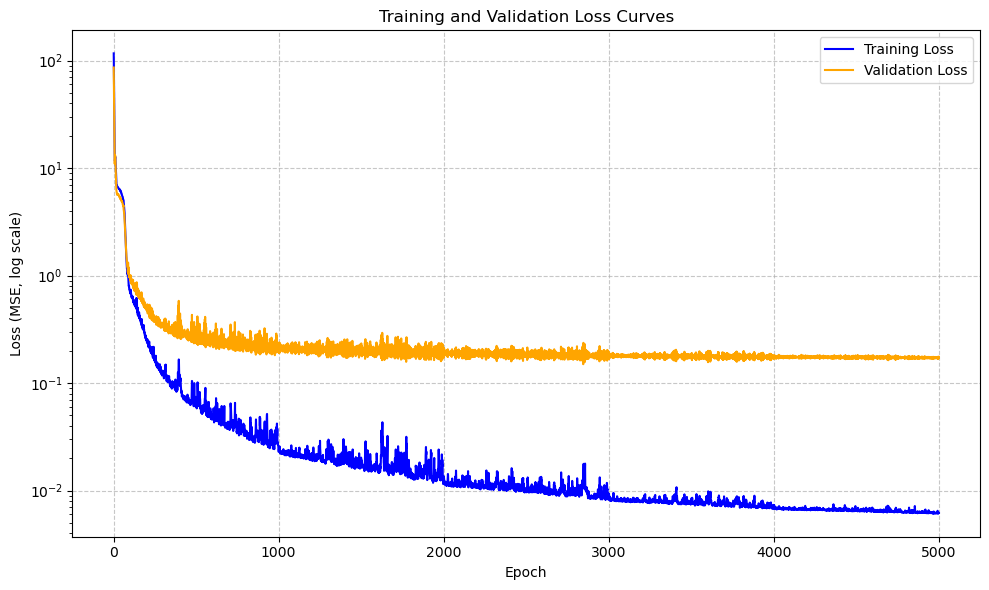

In [7]:
# Loss curve visualization
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), losses['train'], label='Training Loss', color='blue')
plt.plot(range(1, epochs + 1), losses['valid'], label='Validation Loss', color='orange')
plt.xlabel('Epoch')
# plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Optional: Log scale if losses vary widely
plt.yscale('log')
plt.ylabel('Loss (MSE, log scale)')

plt.tight_layout()
plt.show()